
## Hospital Readmission Risk Prediction 

🎯 Aim of the Hospital Readmission Risk Prediction Project ->

The main aim is to develop an end-to-end machine learning system that predicts 
whether a diabetic patient is likely to be readmitted to the hospital within 30 days of discharge,
using the patient's demographic, clinical, and previous hospitalization information.

In [98]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
df = pd.read_csv("data/diabetic_data.csv")

#### Check Top 10 Data From Dataset.

In [100]:
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### check columns_name

## Column Description

- `encounter_id` → Unique hospital encounter ID
- `patient_nbr` → Unique patient ID
- `race` → Patient's race
- `gender` → Patient's gender
- `age` → Patient's age group
- `weight` → Patient's weight
- `admission_type_id` → Type of admission
- `discharge_disposition_id` → Discharge destination
- `admission_source_id` → Admission source
- `time_in_hospital` → Days spent in hospital
- `payer_code` → Insurance/payer code
- `medical_specialty` → Medical specialty
- `num_lab_procedures` → Number of lab procedures
- `num_procedures` → Number of medical procedures
- `num_medications` → Number of medications
- `number_outpatient` → Previous outpatient visits
- `number_emergency` → Previous emergency visits
- `number_inpatient` → Previous inpatient visits
- `diag_1` → Primary diagnosis
- `diag_2` → Secondary diagnosis
- `diag_3` → Third diagnosis
- `number_diagnoses` → Number of diagnoses
- `max_glu_serum` → Maximum glucose result
- `A1Cresult` → HbA1c test result
- `metformin` → Metformin medication status
- `repaglinide` → Repaglinide medication status
- `nateglinide` → Nateglinide medication status
- `chlorpropamide` → Chlorpropamide medication status
- `glimepiride` → Glimepiride medication status
- `acetohexamide` → Acetohexamide medication status
- `glipizide` → Glipizide medication status
- `glyburide` → Glyburide medication status
- `tolbutamide` → Tolbutamide medication status
- `pioglitazone` → Pioglitazone medication status
- `rosiglitazone` → Rosiglitazone medication status
- `acarbose` → Acarbose medication status
- `miglitol` → Miglitol medication status
- `troglitazone` → Troglitazone medication status
- `tolazamide` → Tolazamide medication status
- `examide` → Examide medication status
- `citoglipton` → Citoglipton medication status
- `insulin` → Insulin medication status
- `glyburide-metformin` → Combination medication status
- `glipizide-metformin` → Combination medication status
- `glimepiride-pioglitazone` → Combination medication status
- `metformin-rosiglitazone` → Combination medication status
- `metformin-pioglitazone` → Combination medication status
- `change` → Diabetes medication change
- `diabetesMed` → Diabetes medication prescribed
- `readmitted` → Patient readmission status (Target)

#### check datatypes of each column

In [101]:
df.dtypes.value_counts()

object    37
int64     13
Name: count, dtype: int64

#### Check last 4 Data From Dataset

In [102]:
df.tail(4)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [103]:
## check dataset shape
print("shape:",df.shape)

shape: (101766, 50)


In [104]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

#### summary of dataset

In [106]:
df.describe(include="all")

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766,101766.000000,101766.000000,101766.000000,101766.000000,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,10,NaN,NaN,NaN,NaN,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),?,NaN,NaN,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,98569,NaN,NaN,NaN,NaN,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,2.024006,3.715642,5.754437,4.395987,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,1.445403,5.280166,4.064081,2.985108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### checking null values in dataset

In [107]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

#### check missing values = "?"

In [108]:
df = df.replace("?",np.nan)

In [109]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [110]:
(df.isnull().sum()/ len(df) * 100).sort_values(ascending = False)

weight                      96.858479
max_glu_serum               94.746772
A1Cresult                   83.277322
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
patient_nbr                  0.000000
time_in_hospital             0.000000
admission_source_id          0.000000
num_lab_procedures           0.000000
encounter_id                 0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
gender                       0.000000
age                          0.000000
number_inpatient             0.000000
number_emergency             0.000000
number_outpatient            0.000000
num_medications              0.000000
num_procedures               0.000000
number_diagnoses             0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

In [111]:
# Drop high-missing columns 
df = df.drop(columns=["weight", "payer_code", "medical_specialty", "max_glu_serum"])

In [112]:
df.nunique()

encounter_id                101766
patient_nbr                  71518
race                             5
gender                           3
age                             10
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         716
diag_2                         748
diag_3                         789
number_diagnoses                16
A1Cresult                        3
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride                      4
acetohexamide                    2
glipizide                        4
glyburide                        4
tolbutamide         

In [113]:
# Drop constant columns
# gender column
df = df.drop(columns=["examide", "citoglipton", "metformin-rosiglitazone"])

In [114]:
df["gender"].unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

In [115]:
df["gender"].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [116]:
df = df[df["gender"] != 'Unknown/Invalid']

In [117]:
df["gender"].unique()

array(['Female', 'Male'], dtype=object)

In [118]:
df["gender"].value_counts()

gender
Female    54708
Male      47055
Name: count, dtype: int64

In [119]:
# Dedupe patients BEFORE dropping patient_nbr
df["patient_nbr"].duplicated().sum()

np.int64(30248)

In [120]:
df = df.sort_values("time_in_hospital", ascending = False).drop_duplicates(subset = "patient_nbr",keep = "first")

In [121]:
df.shape

(71515, 43)

In [122]:
df = df.drop(columns = ["patient_nbr","encounter_id"])

In [123]:
df["race"].value_counts(dropna = False)

race
Caucasian          53516
AfricanAmerican    12906
NaN                 1914
Hispanic            1510
Other               1168
Asian                501
Name: count, dtype: int64

In [124]:
df = df.dropna(subset = ["race","diag_1","diag_2","diag_3"])

In [125]:
df.shape

(68463, 41)

In [126]:
df.isnull().sum().sum()

np.int64(56219)

In [127]:
df["readmitted"].value_counts()

readmitted
NO     45646
>30    18093
<30     4724
Name: count, dtype: int64

`NO`--> 45,646:Patient was **not readmitted** after discharge            
`>30`--> 18,093:Patient was readmitted, but **after 30 days**              
`<30`--> 4,724 :Patient was readmitted **within 30 days** (our target) 

In [128]:
df["readmitted"].value_counts(normalize = True) * 100

readmitted
NO     66.672509
>30    26.427413
<30     6.900077
Name: proportion, dtype: float64

In [129]:
df["readmitted"] = df["readmitted"].map({">30":0,"NO":0,"<30":1})

In [130]:
df["readmitted"]

101748    0
101755    0
82291     0
2319      0
97565     0
         ..
87451     0
87474     0
87464     0
87489     0
87477     0
Name: readmitted, Length: 68463, dtype: int64

In [131]:
df["readmitted"].value_counts(normalize =True) *100

readmitted
0    93.099923
1     6.900077
Name: proportion, dtype: float64

In [132]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101748,Caucasian,Female,[40-50),1,4,7,14,69,0,16,...,No,No,Down,No,No,No,No,Ch,Yes,0
101755,Other,Female,[40-50),1,1,7,14,73,6,26,...,No,No,Up,No,No,No,No,Ch,Yes,0
82291,Hispanic,Female,[50-60),1,6,7,14,69,0,25,...,No,No,Steady,No,No,No,No,No,Yes,0
2319,AfricanAmerican,Male,[40-50),1,6,7,14,65,2,34,...,No,No,Up,No,No,No,No,Ch,Yes,0
97565,Caucasian,Male,[50-60),3,1,1,14,63,4,30,...,No,No,Down,No,No,No,No,Ch,Yes,0


In [133]:
df["discharge_disposition_id"].unique()

array([ 4,  1,  6, 15,  2,  3, 11, 22, 18,  5, 25, 13, 14,  8, 23, 27,  7,
       28, 17,  9, 10, 16, 24, 20, 12, 19])

In [134]:
# Remove expired/hospice patients
invalid_discharge_codes = [11,13,14,18,19,20,21,25,26]
df = df[~df["discharge_disposition_id"].isin(invalid_discharge_codes)]

In [135]:
df.shape

(63595, 41)

In [136]:
df["discharge_disposition_id"].unique()

array([ 4,  1,  6, 15,  2,  3, 22,  5,  8, 23, 27,  7, 28, 17,  9, 10, 16,
       24, 12])

In [137]:
missing_final = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_final[missing_final > 0]

A1Cresult    81.825615
dtype: float64

In [138]:
df["A1Cresult"].unique()

array(['>7', '>8', nan, 'Norm'], dtype=object)

In [139]:
# A1Cresult
df["A1Cresult"] = df["A1Cresult"].fillna("Not Tested")

In [140]:
df["A1Cresult"].unique()

array(['>7', '>8', 'Not Tested', 'Norm'], dtype=object)

In [141]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101748,Caucasian,Female,[40-50),1,4,7,14,69,0,16,...,No,No,Down,No,No,No,No,Ch,Yes,0
101755,Other,Female,[40-50),1,1,7,14,73,6,26,...,No,No,Up,No,No,No,No,Ch,Yes,0
82291,Hispanic,Female,[50-60),1,6,7,14,69,0,25,...,No,No,Steady,No,No,No,No,No,Yes,0
2319,AfricanAmerican,Male,[40-50),1,6,7,14,65,2,34,...,No,No,Up,No,No,No,No,Ch,Yes,0
97565,Caucasian,Male,[50-60),3,1,1,14,63,4,30,...,No,No,Down,No,No,No,No,Ch,Yes,0


In [142]:
df["race"].unique()

array(['Caucasian', 'Other', 'Hispanic', 'AfricanAmerican', 'Asian'],
      dtype=object)

In [143]:
df["admission_type_id"].value_counts()

admission_type_id
1    32791
3    12472
2    11679
6     3603
5     2741
8      283
7       17
4        9
Name: count, dtype: int64

In [144]:
invalid_admission_type = [5,6,8]
invalid_admission_source = [9, 15, 17, 20, 21]

print("Admission Type invalid rows:", df["admission_type_id"].isin(invalid_admission_type).sum())
print("Admission Source invalid rows:", df["admission_source_id"].isin(invalid_admission_source).sum())
len(df)

Admission Type invalid rows: 6627
Admission Source invalid rows: 4537


63595

In [145]:
print(f"Admission Type invalid: {6627/63595*100:.2f}%")
print(f"Admission Source invalid: {4537/63595*100:.2f}%")

Admission Type invalid: 10.42%
Admission Source invalid: 7.13%


In [146]:
# Merging invalid/unclear admission_type_id codes (5=Not Available, 6=NULL, 8=Not Mapped) 
# into a single "Unknown" category (99) instead of dropping rows, 
# since these made up ~10.4% of the data — dropping would cause significant data loss.
# Same treatment applied to admission_source_id (9, 15, 17, 20, 21 -> 99), which made up ~7.1%.

df["admission_type_id"] = df["admission_type_id"].replace({5:99,6:99,8:99})
df["admission_source_id"] = df["admission_source_id"].replace({9:99, 15:99, 17:99, 20:99, 21:99})

In [147]:
df.shape

(63595, 41)

In [148]:

print(df["admission_type_id"].value_counts())

print(df["admission_source_id"].value_counts())

admission_type_id
1     32791
3     12472
2     11679
99     6627
7        17
4         9
Name: count, dtype: int64
admission_source_id
7     34674
1     19485
99     4537
4      2074
6      1464
2       767
5       495
3        65
8        11
22        9
10        7
25        2
14        2
11        2
13        1
Name: count, dtype: int64


In [149]:
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
            'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
            'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-pioglitazone']

In [150]:
for col in med_cols:
    print(col,":",df[col].unique())

metformin : ['Up' 'No' 'Steady' 'Down']
repaglinide : ['No' 'Steady' 'Down' 'Up']
nateglinide : ['No' 'Steady' 'Up' 'Down']
chlorpropamide : ['No' 'Steady' 'Up' 'Down']
glimepiride : ['No' 'Up' 'Steady' 'Down']
glipizide : ['No' 'Steady' 'Up' 'Down']
glyburide : ['Steady' 'No' 'Up' 'Down']
tolbutamide : ['No' 'Steady']
pioglitazone : ['No' 'Steady' 'Up' 'Down']
rosiglitazone : ['No' 'Steady' 'Up' 'Down']
acarbose : ['No' 'Steady' 'Up']
miglitol : ['No' 'Up' 'Steady' 'Down']
troglitazone : ['No' 'Steady']
tolazamide : ['No' 'Steady']
insulin : ['Down' 'Up' 'Steady' 'No']
glyburide-metformin : ['No' 'Steady' 'Down' 'Up']
glipizide-metformin : ['No' 'Steady']
glimepiride-pioglitazone : ['No']
metformin-pioglitazone : ['No' 'Steady']


In [151]:
df = df.drop(columns=["glimepiride-pioglitazone"])

In [152]:
print(df["change"].unique())
print(df["diabetesMed"].unique())

['Ch' 'No']
['Yes' 'No']


In [153]:
df.shape

(63595, 40)

In [154]:
df.isnull().sum().sum()

np.int64(0)

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
df.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted
count,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000
mean,11.790125,2.709537,11.527935,4.741662,44.070351,1.484834,16.459313,0.322337,0.133281,0.348817,7.452378,0.071342
std,29.755058,3.814780,24.394427,3.154538,20.066057,1.770411,8.507192,1.153729,0.674432,0.847838,1.858929,0.257397
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,1.000000,1.000000,1.000000,2.000000,32.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.000000,1.000000,7.000000,4.000000,45.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,3.000000,3.000000,7.000000,6.000000,58.000000,2.000000,21.000000,0.000000,0.000000,0.000000,9.000000,0.000000
max,99.000000,28.000000,99.000000,14.000000,132.000000,6.000000,81.000000,40.000000,63.000000,19.000000,16.000000,1.000000


### EDA(Exploratory_Data_Analysis)

#### Target variable distribution

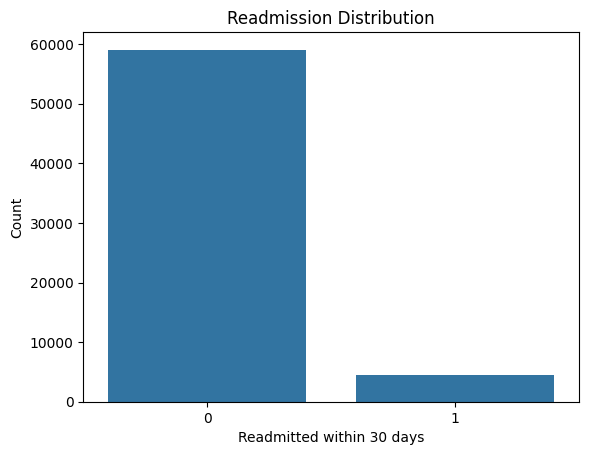

In [157]:
sns.countplot(x = "readmitted",data=df)
plt.title("Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Count")
plt.show()

In [158]:
df.select_dtypes(include = ['int64','float64']).columns.tolist()

['admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'readmitted']

In [159]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_outpatient', 'number_emergency',
                 'number_inpatient', 'number_diagnoses']

numeric_cols

['time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']

In [160]:
df[numeric_cols].describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000,63595.000000
mean,4.741662,44.070351,1.484834,16.459313,0.322337,0.133281,0.348817,7.452378
std,3.154538,20.066057,1.770411,8.507192,1.153729,0.674432,0.847838,1.858929
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,2.000000,32.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,45.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,58.000000,2.000000,21.000000,0.000000,0.000000,0.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,40.000000,63.000000,19.000000,16.000000


#### Numeric Feature Analysis (df.describe())

- `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, 
  and `number_diagnoses` show roughly symmetric distributions with no major issues.

- `number_outpatient`, `number_emergency`, and `number_inpatient` are heavily 
  right-skewed (zero-inflated): the median is 0 for all three, yet the maximum 
  values (40, 63, and 19 respectively) indicate a small subset of patients with 
  very frequent prior hospital utilization. This pattern likely reflects a group 
  of chronic/high-risk patients — a segment expected to have elevated readmission 
  risk, making these features potentially strong predictors despite their skew.

- These skewed features will require outlier treatment (e.g., capping at the 
  99th percentile) during the Feature Engineering phase before modeling.

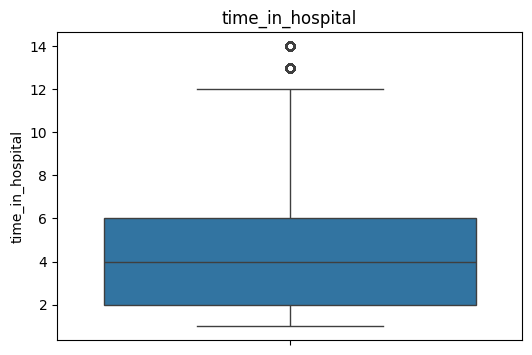

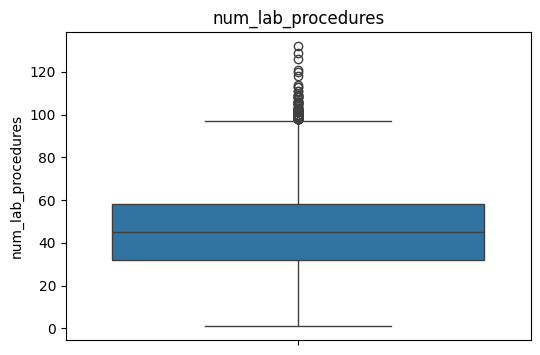

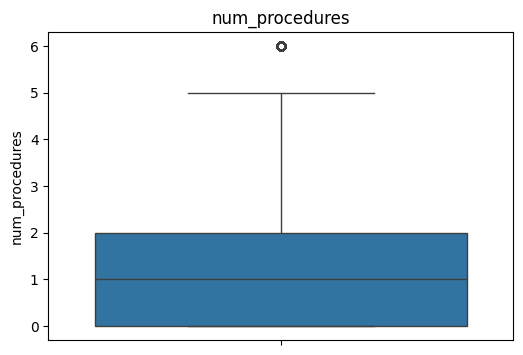

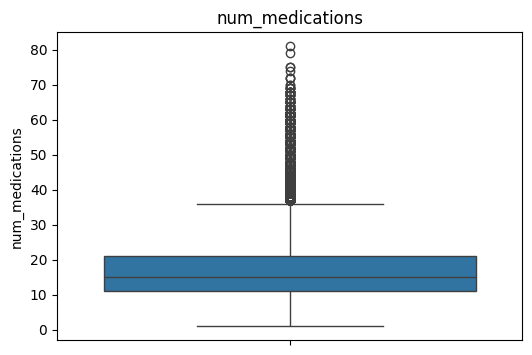

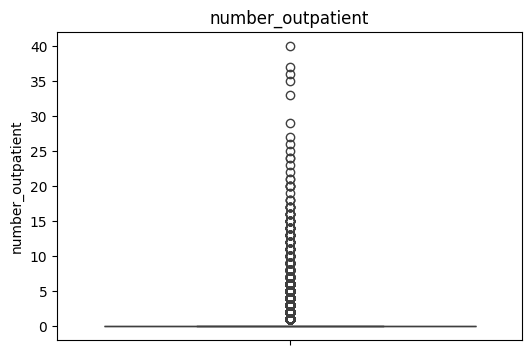

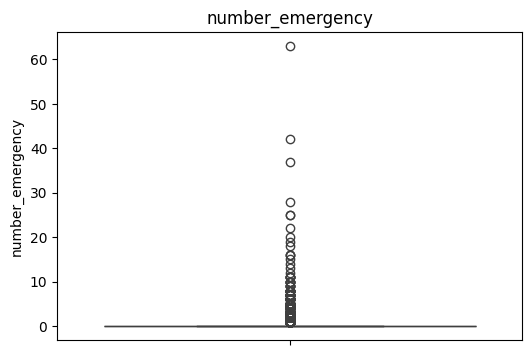

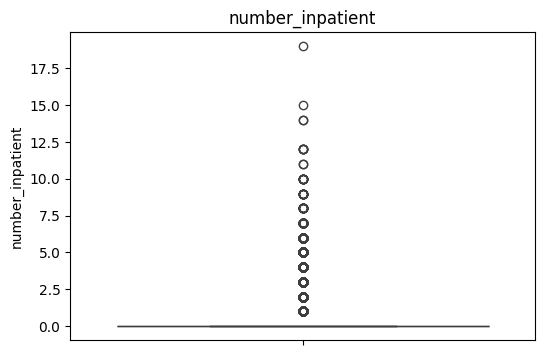

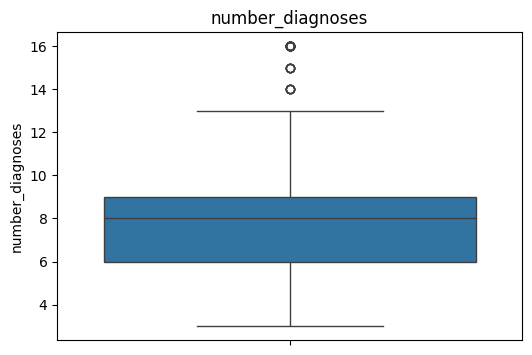

In [161]:
data_num = df[numeric_cols]  

for i in data_num.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data_num[i])
    plt.title(i)
    plt.show()

In [162]:
for col in ['number_outpatient', 'number_emergency', 'number_inpatient']:
    print(f"\n{col}:")
    print(df.groupby('readmitted')[col].mean())
    


number_outpatient:
readmitted
0    0.317586
1    0.384175
Name: number_outpatient, dtype: float64

number_emergency:
readmitted
0    0.127857
1    0.203879
Name: number_emergency, dtype: float64

number_inpatient:
readmitted
0    0.315961
1    0.776504
Name: number_inpatient, dtype: float64


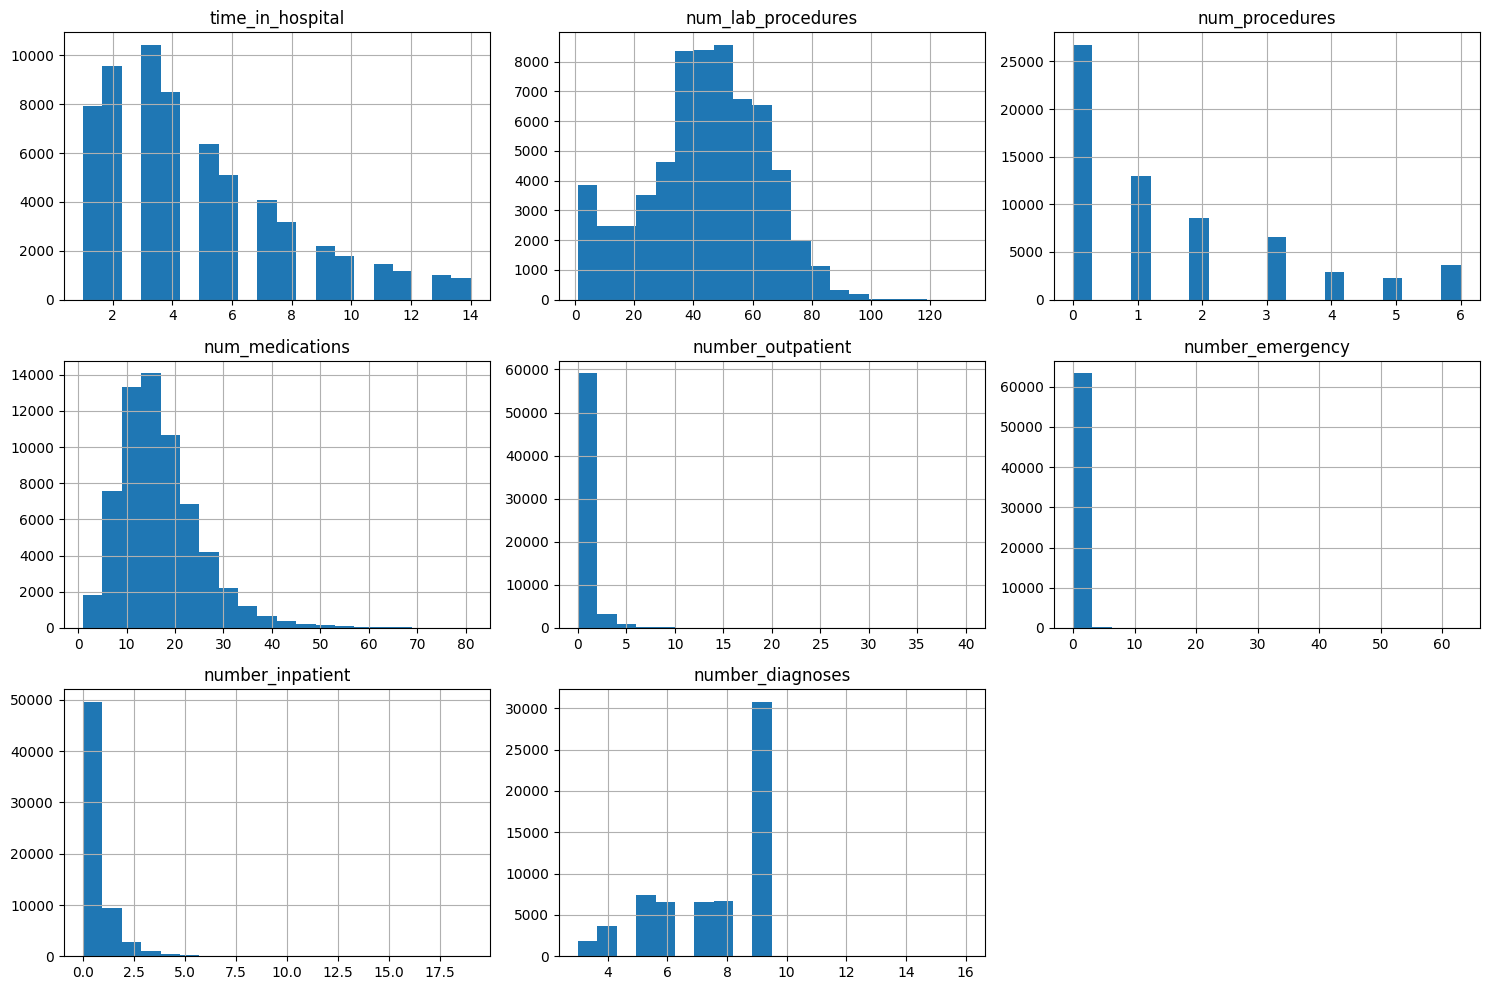

In [163]:
# Distribution of Numeric Feature
df[numeric_cols].hist(figsize=(15,10),bins=20)
plt.tight_layout()
plt.show()

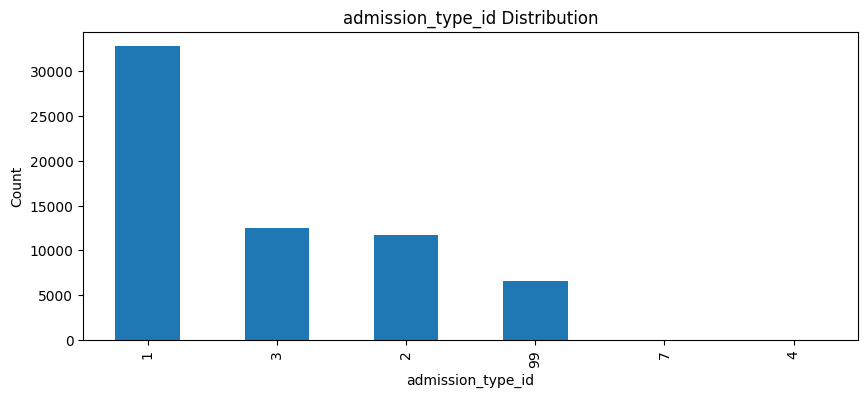

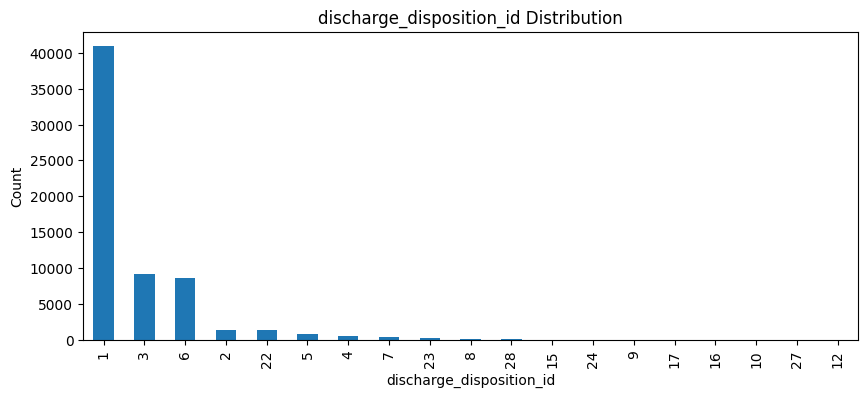

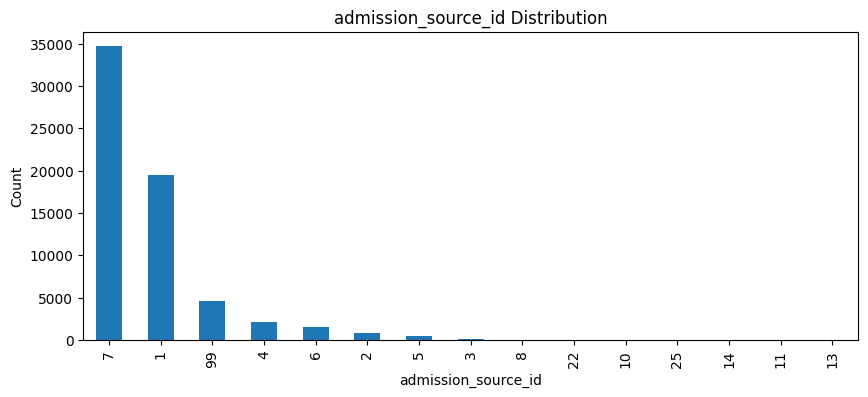

In [164]:
# Distribution of categorical columns
categorical_id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for col in categorical_id_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

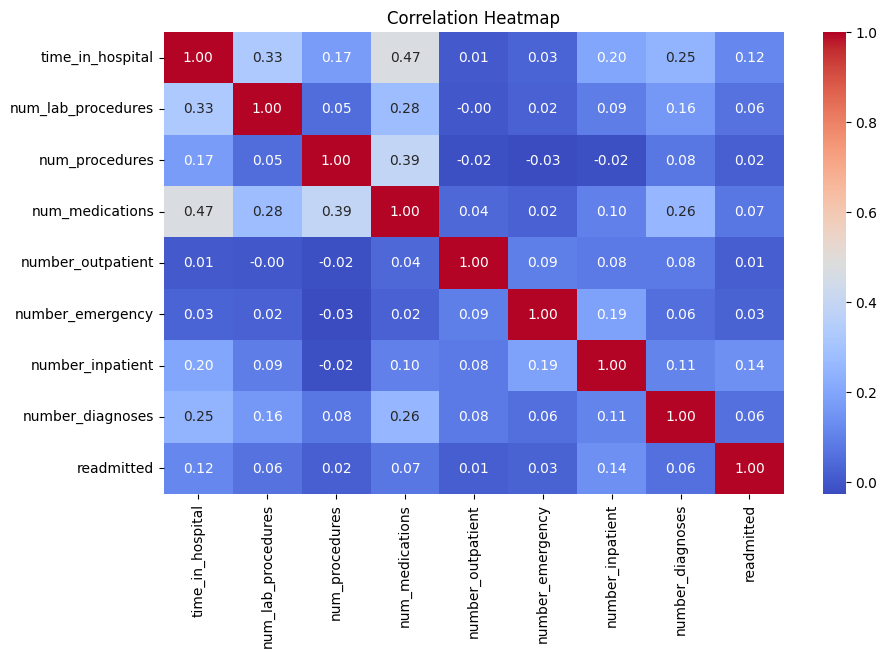

In [165]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols + ['readmitted']].corr(),annot = True,cmap = "coolwarm",fmt = '.2f')
plt.title("Correlation Heatmap")
plt.show()

#### Correlation Heatmap — Key Findings

- Among all numeric features, `number_inpatient` shows the strongest correlation 
  with readmission (0.14), consistent with earlier findings from boxplot and 
  mean-comparison analysis. This reinforces it as the most reliable individual 
  numeric predictor.

- All correlations with the target are relatively weak (max 0.14), suggesting 
  that no single numeric feature strongly predicts readmission on its own. 
  This is expected for a complex healthcare outcome — predictive power will 
  likely come from combining numeric features with categorical ones 
  (e.g., diagnosis category, A1C result, age) and from non-linear feature 
  interactions that tree-based models (Random Forest, XGBoost) can capture 
  better than linear correlation.

- Moderate correlation exists between `num_medications` and `time_in_hospital` 
  (0.47), and between `num_procedures` and `num_medications` (0.39), but not 
  strong enough to indicate a serious multicollinearity concern.

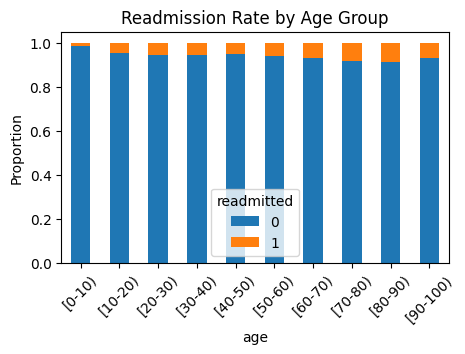

In [166]:
# Age vs readmitted
pd.crosstab(df['age'], df['readmitted'], normalize='index').plot(kind='bar', stacked=True, figsize=(5,3))
plt.title('Readmission Rate by Age Group')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

In [167]:
pd.crosstab(df["age"], df["readmitted"], normalize = "index" )*100

readmitted,0,1
age,,
[0-10),98.305085,1.694915
[10-20),95.136778,4.863222
[20-30),94.484912,5.515088
[30-40),94.537815,5.462185
[40-50),94.596814,5.403186
[50-60),94.116603,5.883397
[60-70),93.019843,6.980157
[70-80),91.837999,8.162001
[80-90),91.248553,8.751447


#### Age vs Readmission — Key Findings

A clear increasing trend is observed: readmission rate rises steadily from 
1.69% in the [0-10) age group to a peak of 8.75% in the [80-90) group — more 
than a 5x increase. This aligns with clinical expectations, as older patients 
typically have more chronic conditions and higher complication risk. The 
slight dip in the [90-100) group (7.19%) is likely due to a much smaller 
sample size in that bracket, making the estimate less stable.


race:
readmitted               0         1
race                                
AfricanAmerican  93.388642  6.611358
Asian            94.017094  5.982906
Caucasian        92.678247  7.321753
Hispanic         93.586006  6.413994
Other            94.309701  5.690299


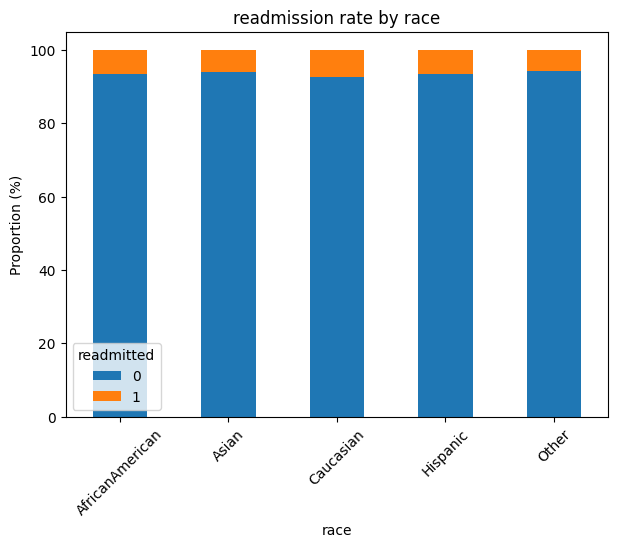


gender:
readmitted          0         1
gender                         
Female      93.011750  6.988250
Male        92.698563  7.301437


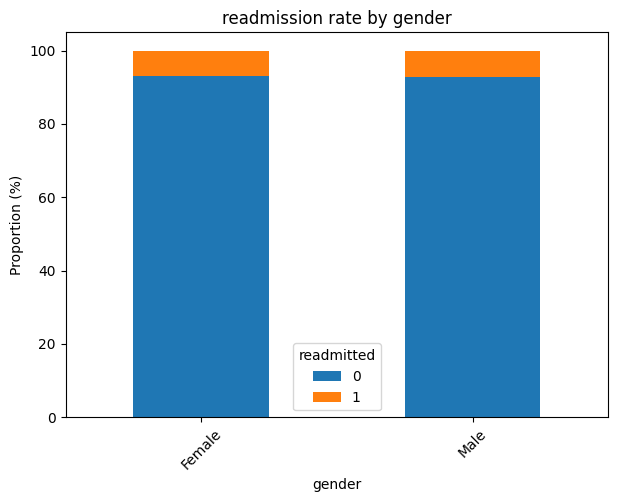

In [168]:
for col in ['race','gender']:
    result = pd.crosstab(df[col] ,df["readmitted"], normalize = "index") *100
    print(f"\n{col}:")
    print(result)

    result.plot(kind = "bar",stacked=True,figsize = (7,5))
    plt.title(f'readmission rate by {col}')
    plt.ylabel('Proportion (%)')
    plt.xticks(rotation=45)
    plt.show()


#### Race & Gender vs Readmission — Key Findings

Both `race` and `gender` show minimal variation in readmission rates:
- Race: ranges from 5.69% (Other) to 7.32% (Caucasian) — only a 1.6 
  percentage point spread.
- Gender: Female (6.99%) vs Male (7.30%) — a negligible 0.31 point difference.

Compared to `age` (1.69% to 8.75%, a 7-point spread) and `number_inpatient` 
(where readmitted patients had 2.4x higher prior inpatient visits), these 
demographic factors show substantially weaker relationships with readmission. 
This is a favorable finding from a fairness perspective — it suggests the 
model's predictive power is more likely to be driven by clinical and 
utilization history rather than demographic attributes.

In [169]:
categorical_cols_to_check = ['admission_type_id', 'discharge_disposition_id', 
                               'admission_source_id', 'A1Cresult', 'insulin', 
                               'change', 'diabetesMed']

for col in categorical_cols_to_check:
    print(f"{col}:")
    
    result = pd.crosstab(df[col], df['readmitted'], normalize='index') * 100
    print(result.sort_values(by=1, ascending=False))

admission_type_id:
readmitted                  0          1
admission_type_id                       
4                   88.888889  11.111111
99                  91.866606   8.133394
2                   92.542170   7.457830
1                   92.769357   7.230643
3                   93.946440   6.053560
7                  100.000000   0.000000
discharge_disposition_id:
readmitted                         0          1
discharge_disposition_id                       
12                         50.000000  50.000000
15                         61.538462  38.461538
28                         75.675676  24.324324
22                         81.208548  18.791452
9                          83.333333  16.666667
5                          84.772182  15.227818
8                          88.311688  11.688312
2                          88.872936  11.127064
3                          88.937330  11.062670
6                          91.753300   8.246700
4                          92.957746   7.042254
7  

#### Categorical Features vs Readmission — Summary

- **discharge_disposition_id** shows a meaningful pattern: patients discharged 
  home (~5.3%) have notably lower readmission risk than those transferred to 
  other care facilities (~15%), suggesting discharge destination reflects 
  case severity.
- **insulin dosage changes** (Up/Down ~8.5%) show slightly higher readmission 
  risk than stable/no insulin (~6-7.5%), consistent with dose changes 
  signaling less stable glycemic control.
- **A1Cresult** showed almost no relationship with readmission (6.96%-7.16% 
  across all categories) — a somewhat unexpected finding given its clinical 
  relevance to diabetes management.
- **admission_type_id, admission_source_id, change, diabetesMed** show only 
  weak associations with readmission.